In [109]:
import geopandas as gpd
import fiona

# Path to swissTLM3D, swissBOUNDARIES3D and Corine Land Cover
tlm_path = "C:/ZHAW/5.Semester/PA2/data/SWISSTLM3D_2025.gpkg"
boundaries_path = "C:/ZHAW/5.Semester/PA2/data/swissBOUNDARIES3D_1_5_LV95_LN02.gpkg"
clc_path = "C:/ZHAW/5.Semester/PA2/data/Results/U2018_CLC2018_V2020_20u1.gpkg"


# List all layers
layers = fiona.listlayers(tlm_path)
print(f"tlm layers: {layers}")  
layers = fiona.listlayers(boundaries_path)
print(f"boundary layers: {layers}") 
layers = fiona.listlayers(clc_path)
print(f"clc layers: {layers}")

tlm layers: ['tlm_strassen_aus_einfahrt', 'tlm_bb_bodenbedeckung', 'tlm_bb_einzelbaum_gebuesch', 'tlm_eo_einzelobjekt', 'tlm_oev_eisenbahn', 'tlm_gewaesser_fliessgewaesser', 'tlm_namen_flurname', 'tlm_areale_freizeitareal', 'tlm_bauten_gebaeude_footprint', 'tlm_namen_gebietsname', 'tlm_name_gelaendename', 'tlm_oev_haltestelle', 'tlm_bauten_leitung', 'tlm_bauten_mauer', 'tlm_namen_name_pkt', 'tlm_areale_nutzungsareal', 'tlm_oev_schifffahrt', 'tlm_areale_schutzgebiet', 'tlm_namen_siedlungsname', 'tlm_bauten_sportbaute_lin', 'tlm_bauten_sportbaute_ply', 'tlm_bauten_staubaute', 'tlm_gewaesser_stehendes_gewaesser', 'tlm_strassen_strasse', 'tlm_strassen_strasseninfo', 'tlm_oev_uebrige_bahn', 'tlm_bauten_verbauung', 'tlm_areale_verkehrsareal', 'tlm_bauten_verkehrsbaute_lin', 'tlm_bauten_verkehrsbaute_ply', 'tlm_bauten_versorgungsbaute_pkt', 'tlm_bb_glamos', 'tlm_bauten_leitung_stromtrasse', 'tlm_areale_nutzungsareal_schule', 'tlm_areale_schule', 'tlm_strassen_strassenname', 'tlm_strassen_stra

Landcover

SwissTLM3d

In [110]:
# Filter canton sh
cantons = gpd.read_file(boundaries_path, layer="tlm_kantonsgebiet")

sh = cantons[cantons["name"] == "Schaffhausen"]

# load swisstlm data
landcover = gpd.read_file(tlm_path, layer="tlm_bb_bodenbedeckung")

print(len(landcover))

# Clip: only objects within sh borders
landcover_sh = gpd.clip(landcover, sh)

print(len(landcover_sh))
print(landcover_sh.head())

842825
2876
                                          uuid datum_aenderung  \
343898  {11B998BC-C1E3-4BA9-83C9-50EA3F27C32A}      2019-12-11   
760012  {E37F6B10-F29F-4E67-90ED-D59024BA1BE4}      2019-12-11   
347267  {1744BDE7-2E11-46A5-99CF-876035538503}      2020-01-08   
241816  {A3C86332-5092-47B0-8D3E-42D58817E01A}      2019-12-11   
241817  {C3256931-8C77-467A-A89F-0EB8C37145C9}      2020-01-08   

       datum_erstellung  erstellung_jahr  erstellung_monat grund_aenderung  \
343898       2015-03-03           2014.0               6.0      Verbessert   
760012       2019-12-11           2019.0               6.0      Verbessert   
347267       2015-03-19           2014.0               6.0      Verbessert   
241816       2009-04-24           2008.0               5.0      Verbessert   
241817       2009-04-24           2008.0               5.0      Verbessert   

         herkunft  herkunft_jahr  herkunft_monat           objektart  \
343898  swisstopo           2019             6.0  

Corine Landcover

In [111]:
import pandas as pd

landcover_sh_clc = gpd.read_file(clc_path, layer="U2018_CLC2018_V2020_20u1")

print(landcover_sh_clc.columns)

# load CLC_legend.csv
clc_legend = pd.read_csv("C:/ZHAW/5.Semester/PA2/data/Results/Info/Legend/Vector/CLC_legend.csv", sep=';')

Index(['OBJECTID', 'Code_18', 'Remark', 'Area_Ha', 'Shape_Length',
       'Shape_Area', 'geometry'],
      dtype='object')


In [112]:
print(type(landcover_sh_clc["Code_18"][1]))

# change datatype
landcover_sh_clc['Code_18'] = landcover_sh_clc['Code_18'].astype(int)

print(type(landcover_sh_clc["Code_18"][1]))

<class 'str'>
<class 'numpy.int64'>


In [113]:
# load CLC_legend.csv
clc_legend = pd.read_csv("C:/ZHAW/5.Semester/PA2/data/Results/Info/Legend/Vector/CLC_legend.csv", sep=';')

# legend table
print("Legend:")
print(clc_legend.head())

Legend:
   GRID_CODE  CLC_CODE                                      LABEL3  \
0          1       111                     Continuous urban fabric   
1          2       112                  Discontinuous urban fabric   
2          3       121              Industrial or commercial units   
3          4       122  Road and rail networks and associated land   
4          5       123                                  Port areas   

           RGB  
0  230-000-077  
1  255-000-000  
2  204-077-242  
3  204-000-000  
4  230-204-204  


In [114]:
# Add the landcovernames to the data
landcover_sh_clc = landcover_sh_clc.merge(
    clc_legend[['CLC_CODE', 'LABEL3']],
    left_on='Code_18',
    right_on='CLC_CODE',
    how='left'
)

In [115]:

print(landcover_sh_clc.head())

   OBJECTID  Code_18 Remark     Area_Ha  Shape_Length    Shape_Area  \
0   1017625      112   None   80.820126   7055.077298  8.082013e+05   
1   1017783      112   None  161.691835  10461.377355  1.616918e+06   
2   1017791      112   None    0.146694    271.229232  1.466945e+03   
3   1017795      112   None  161.120051  10432.388571  1.611201e+06   
4   1017799      112   None   27.522222   3144.386954  2.752222e+05   

                                            geometry  CLC_CODE  \
0  MULTIPOLYGON (((8.57405 47.57627, 8.57286 47.5...       112   
1  MULTIPOLYGON (((8.86286 47.65489, 8.85973 47.6...       112   
2  MULTIPOLYGON (((8.43461 47.65998, 8.43366 47.6...       112   
3  MULTIPOLYGON (((8.87462 47.6598, 8.87446 47.65...       112   
4  MULTIPOLYGON (((8.49465 47.66356, 8.49619 47.6...       112   

                       LABEL3  
0  Discontinuous urban fabric  
1  Discontinuous urban fabric  
2  Discontinuous urban fabric  
3  Discontinuous urban fabric  
4  Discontinuous

In [116]:
import numpy as np

# print all landcovertypes in clc data
print(np.unique(landcover_sh_clc["LABEL3"]))

['Broad-leaved forest' 'Complex cultivation patterns' 'Coniferous forest'
 'Discontinuous urban fabric' 'Industrial or commercial units'
 'Land principally occupied by agriculture, with significant areas of natural vegetation'
 'Mineral extraction sites' 'Mixed forest' 'Non-irrigated arable land'
 'Pastures' 'Road and rail networks and associated land' 'Vineyards'
 'Water bodies' 'Water courses']


Show Landcover

In [117]:
# To check the CRS of your SwissTLM3D data:
print("CRS of SwissTLM3D:", landcover_sh.crs)

# To check the CRS of your Corine Landcover data:
print("CRS of Corine Landcover:", landcover_sh_clc.crs)

CRS of SwissTLM3D: EPSG:2056
CRS of Corine Landcover: EPSG:4326


In [118]:
landcover_sh_clc_proj = landcover_sh_clc.to_crs(landcover_sh.crs)

# To check the CRS of your Corine Landcover data:
print("CRS of Corine Landcover:", landcover_sh_clc_proj.crs)

CRS of Corine Landcover: EPSG:2056


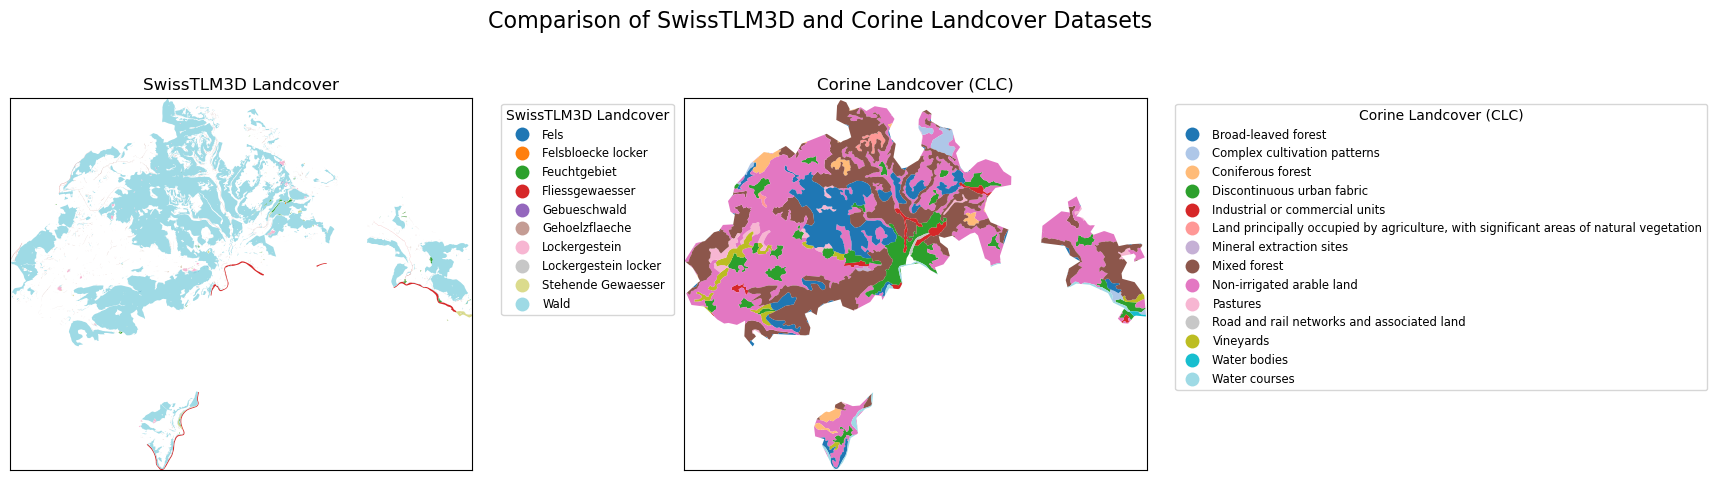

In [119]:
import matplotlib.pyplot as plt

# Set up the figure and two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 5)) # Increased width for external legends

# Plot 1: SwissTLM3D Landcover
landcover_sh.plot(
    column='objektart', 
    ax=axes[0], 
    legend=True, 
    legend_kwds={
        'title': "SwissTLM3D Landcover",
        'loc': 'upper left',       # Anchor the legend in the upper left corner of the bbox
        'bbox_to_anchor': (1.05, 1), # Position it to the right of the axes[0] plot
        'fontsize': 'small'
    },
    cmap='tab20'
)
axes[0].set_title('SwissTLM3D Landcover')

# Plot 2: Corine Landcover (CLC)
landcover_sh_clc_proj.plot(
    column='LABEL3',
    ax=axes[1],
    legend=True,
    legend_kwds={
        'title': "Corine Landcover (CLC)",
        'loc': 'upper left',       # Anchor the legend in the upper left corner of the bbox
        'bbox_to_anchor': (1.05, 1), # Position it to the right of the axes[1] plot
        'fontsize': 'small'
    },
    cmap='tab20'
)
axes[1].set_title('Corine Landcover (CLC)')

# **Optional but recommended:** Set common map limits if comparing the same area
# Use the bounds of the more detailed dataset (SwissTLM3D) to zoom in the view
x_min, y_min, x_max, y_max = landcover_sh.total_bounds
axes[0].set_xlim(x_min, x_max)
axes[0].set_ylim(y_min, y_max)
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(y_min, y_max)

# Remove axis labels/ticks for a cleaner map look
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

# Display the plots
plt.suptitle("Comparison of SwissTLM3D and Corine Landcover Datasets", fontsize=16)
# Use 'tight_layout' to automatically adjust subplots and make room for the legends.
# Note: Since we've used bbox_to_anchor, we often rely on tight_layout to finalize spacing.
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

Fill SwissTLM Landcover with Corine Landcover

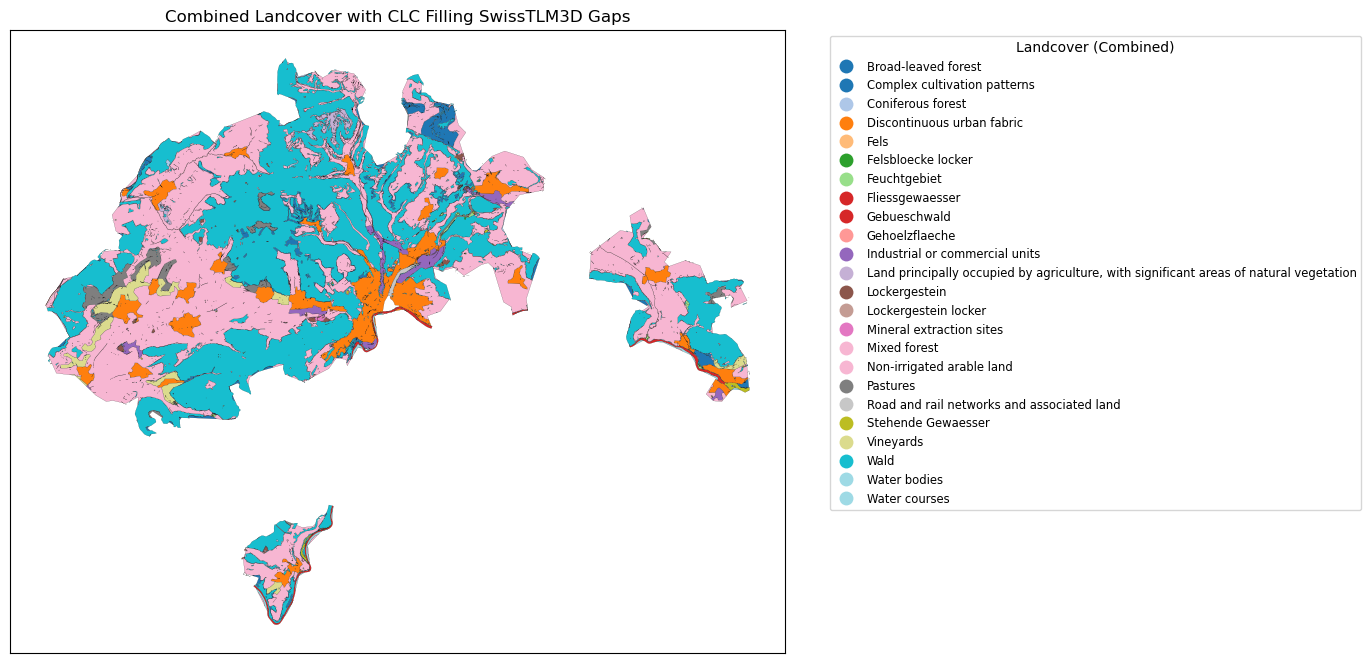

In [120]:
import geopandas as gpd
import pandas as pd

# Calculate the area of CLC that overlaps the SwissTLM3D area
# The 'overlay' function with how='difference' gives us the parts of CLC that DO NOT intersect swisstlm_boundary.
clc_fill_areas = gpd.overlay(landcover_sh_clc_proj, landcover_sh, how='difference', keep_geom_type=False)

# Rename the CLC attribute column in the filler data

# Identify the columns needed for the final combined GeoDataFrame
# 'LABEL3' contains the description you want. We map it to 'objektart' for consistency.
clc_fill_areas = clc_fill_areas.rename(columns={'LABEL3': 'objektart'})
# Keep only the necessary columns and the geometry, similar to the base layer
clc_fill_areas = clc_fill_areas[['objektart', 'geometry']]


# 3. Combine/Merge the two datasets
#    The base layer (SwissTLM3D) plus the 'hole filler' layer (CLC)
landcover_filled = pd.concat([landcover_sh[['objektart', 'geometry']], clc_fill_areas])

# Set the result as a GeoDataFrame (for safety) and re-index
landcover_filled = gpd.GeoDataFrame(landcover_filled, crs=landcover_sh.crs)
landcover_filled.reset_index(drop=True, inplace=True)


# Visualize the resulting map with filled holes
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

landcover_filled.plot(
    column='objektart', 
    ax=ax, 
    legend=True, 
    legend_kwds={
        'title': "Landcover (Combined)",
        'loc': 'upper left',
        'bbox_to_anchor': (1.05, 1),
        'fontsize': 'small'
    },
    cmap='tab20',
    edgecolor='black', 
    linewidth=0.1
)

ax.set_title('Combined Landcover with CLC Filling SwissTLM3D Gaps')
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

plt.show()

In [121]:
np.unique(landcover_filled["objektart"])

array(['Broad-leaved forest', 'Complex cultivation patterns',
       'Coniferous forest', 'Discontinuous urban fabric', 'Fels',
       'Felsbloecke locker', 'Feuchtgebiet', 'Fliessgewaesser',
       'Gebueschwald', 'Gehoelzflaeche', 'Industrial or commercial units',
       'Land principally occupied by agriculture, with significant areas of natural vegetation',
       'Lockergestein', 'Lockergestein locker',
       'Mineral extraction sites', 'Mixed forest',
       'Non-irrigated arable land', 'Pastures',
       'Road and rail networks and associated land', 'Stehende Gewaesser',
       'Vineyards', 'Wald', 'Water bodies', 'Water courses'], dtype=object)

In [122]:
harmonization_map = {
    # --- Forest / Wooded Areas ---
    'Broad-leaved forest': 'Forest',
    'Coniferous forest': 'Forest',
    'Mixed forest': 'Forest',
    'Wald': 'Forest',
    'Gebueschwald': 'Scrub / Bushland',
    'Gehoelzflaeche': 'Scrub / Bushland', 
    
    # --- Agricultural Areas ---
    'Complex cultivation patterns': 'Agriculture',
    'Non-irrigated arable land': 'Agriculture',
    'Vineyards': 'Agriculture',
    'Pastures': 'Pastures',
    'Land principally occupied by agriculture, with significant areas of natural vegetation': 'Mixed Agriculture / Natural',
    
    # --- Artificial Areas ---
    'Discontinuous urban fabric': 'Urban Fabric',
    'Industrial or commercial units': 'Industrial / Commercial',
    'Road and rail networks and associated land': 'Infrastructure',
    'Mineral extraction sites': 'Extraction Sites',
    
    # --- Natural / Semi-natural Areas ---
    'Feuchtgebiet': 'Wetland',
    'Fels': 'Bare Rock / Scree',
    'Felsbloecke locker': 'Bare Rock / Scree',
    'Lockergestein': 'Bare Rock / Scree',
    'Lockergestein locker': 'Bare Rock / Scree',

    # --- Water (TO BE DELETED/FILTERED) ---
    'Fliessgewaesser': 'Water',
    'Stehende Gewaesser': 'Water',
    'Water bodies': 'Water',
    'Water courses': 'Water'
}

# Add a specific label for any potential unmapped areas, although mapping all is better
# landcover_filled['objektart'] = landcover_filled['objektart'].fillna('Unclassified')

In [123]:
# Create the new standardized column
landcover_filled['Standard_LC_Name'] = landcover_filled['objektart'].map(harmonization_map)

# Filter the data to exclude all rows categorized as 'Water'
# This removes 'Fliessgewaesser', 'Stehende Gewaesser', 'Water bodies', and 'Water courses'.
landcover_filtered = landcover_filled[landcover_filled['Standard_LC_Name'] != 'Water'].copy()

# Optional: Drop the temporary mapping column if 'objektart' itself was used for mapping
# landcover_filtered = landcover_filtered.drop(columns=['objektart'], axis=1, errors='ignore')

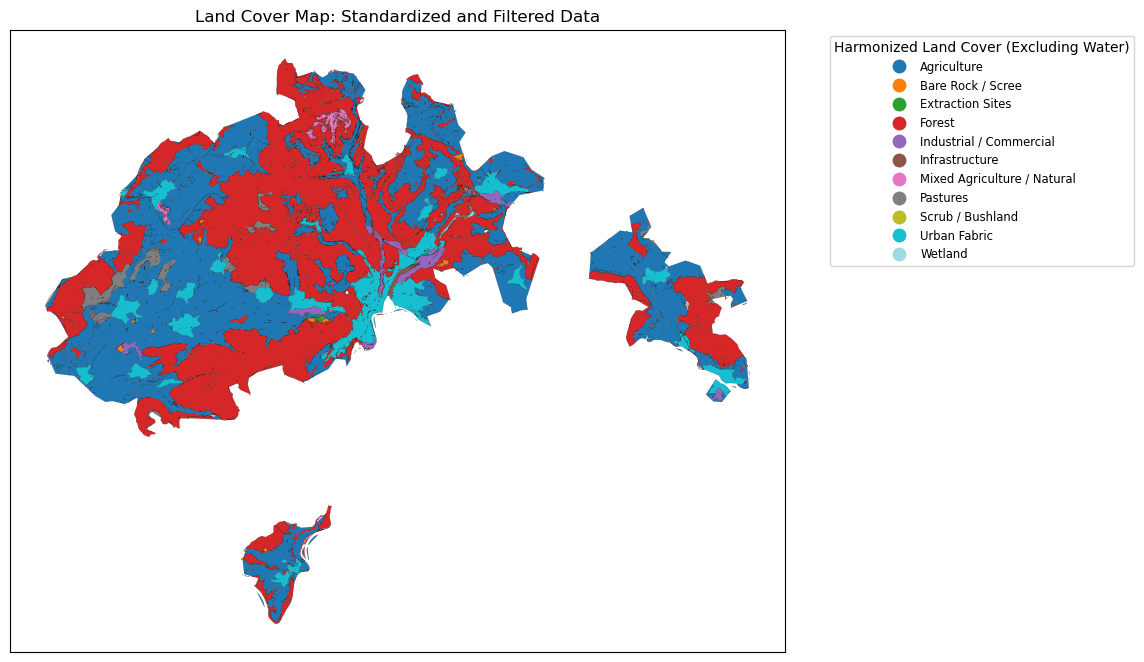

In [124]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot the filtered GeoDataFrame using the new standardized names
landcover_filtered.plot(
    column='Standard_LC_Name', 
    ax=ax, 
    legend=True, 
    legend_kwds={
        'title': "Harmonized Land Cover (Excluding Water)",
        'loc': 'upper left',
        'bbox_to_anchor': (1.05, 1), # Place legend outside the plot area
        'fontsize': 'small'
    },
    cmap='tab20', # Reusing a categorical color map
    edgecolor='black', 
    linewidth=0.1
)

ax.set_title('Land Cover Map: Standardized and Filtered Data')

# Remove axis elements for a map view
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

plt.show()

Cost Surfaces

In [155]:
import numpy as np
from rasterio.features import rasterize
from rasterio.transform import from_bounds

def create_cost_raster(gdf, cost_column, resolution_m = 10, fill_value=0):
    """
    Rasterizes a GeoDataFrame's cost values onto a NumPy array grid.

    Args:
        gdf (GeoDataFrame): The input GeoDataFrame (e.g., landcover_filtered, water_combined).
        cost_column (str): The name of the column containing the standardized cost values (1-10).
        resolution_m (int): The target resolution for the raster cells in meters (e.g., 10).
        total_bounds (tuple, optional): (xmin, ymin, xmax, ymax) of the definitive overall extent. 
                                        If None, uses the bounds of the input GDF.
        fill_value (int, optional): The No-Data value for areas outside the features. Defaults to 0.

    Returns:
        tuple: (NumPy array of the cost surface, Affine transform, out_shape, bounds)
    """
    
    # 1. Define the Extent and Dimensions (crucial for alignment)
    
    # Use the provided total bounds or the GDF's own bounds
    xmin, ymin, xmax, ymax = sh.total_bounds

    width_in_meters = xmax - xmin
    height_in_meters = ymax - ymin
    
    # Calculate rows and columns based on the fixed bounds and resolution
    cols = int(np.ceil(width_in_meters / resolution_m))
    rows = int(np.ceil(height_in_meters / resolution_m))

    out_shape = (rows, cols)
    
    # Calculate the affine transform
    transform = from_bounds(xmin, ymin, xmax, ymax, cols, rows)
    
    # 2. Prepare Data for Rasterization
    
    # Create (geometry, value) tuples, filtering out NaN values
    # We use fillna(fill_value) for safety, but check against > 0 to exclude 
    # areas that shouldn't be rasterized (e.g., non-cost features).
    shapes = [
        (geom, value)
        for geom, value in zip(gdf.geometry, gdf[cost_column].fillna(fill_value))
        if value > fill_value # Only rasterize features with a positive cost
    ]

    # 3. Rasterize the Cost Values
    
    # Create an empty array initialized with the fill_value
    raster_array = np.full(out_shape, fill_value, dtype=np.int16)
    
    cost_surface = rasterize(
        shapes=shapes,
        out=raster_array, # Burn into the existing array
        transform=transform,
        fill=fill_value,
        all_touched=True,
        dtype=np.int16
    )
    
    return (cost_surface, transform, out_shape, (xmin, ymin, xmax, ymax))

In [125]:
cost_values = {
    'Pastures': 6,
    'Agriculture': 7,
    'Infrastructure': 9,
    'Urban Fabric': 10,
    'Mixed Agriculture / Natural': 3,
    'Scrub / Bushland': 1,
    'Forest': 2,
    'Wetland': 5,
    'Bare Rock / Scree': 4,
    'Extraction Sites': 8  # Also high resistance
}

# Apply the cost mapping to a new column in your GeoDataFrame
landcover_filtered['Cost_Value'] = landcover_filtered['Standard_LC_Name'].map(cost_values)

In [126]:
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_bounds
import matplotlib.pyplot as plt
import numpy as np

# Define the target resolution in meters (e.g., 20m)
resolution_meters = 10

# Get the bounding box of your data
xmin, ymin, xmax, ymax = landcover_filtered.total_bounds

# Determine the number of rows and columns based on the bounding box and resolution
width_in_meters = xmax - xmin
height_in_meters = ymax - ymin
cols = int(np.ceil(width_in_meters / resolution_meters))
rows = int(np.ceil(height_in_meters / resolution_meters))

# Calculate the affine transform (maps pixel coordinates to geographic coordinates)
transform = from_bounds(xmin, ymin, xmax, ymax, cols, rows)

# Create an empty output array initialized with NoData value (e.g., 0)
out_shape = (rows, cols)
fill_value = 0 # Areas without defined landcover will have this value
raster_array = np.full(out_shape, fill_value, dtype=np.int16)

# Prepare the data for rasterize: (geometry, value) tuples
shapes = [(geom, value) for geom, value in zip(landcover_filtered.geometry, landcover_filtered.Cost_Value)]

In [127]:
# Use rasterio.features.rasterize to create the cost surface
cost_surface_landcover = rasterize(
    shapes=shapes,
    out_shape=out_shape,
    transform=transform,
    fill=fill_value,
    all_touched=True, # Includes all pixels touched by the feature, not just the center
    dtype=np.int16
)

print("Cost Surface (NumPy Array) created with shape:", cost_surface_landcover.shape)

Cost Surface (NumPy Array) created with shape: (2841, 3540)


In [144]:
cost_surface_landcover = np.ma.masked_where(cost_surface_landcover == fill_value, cost_surface_landcover)

C:\Users\Lukas\AppData\Local\Temp\ipykernel_9072\1246206091.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


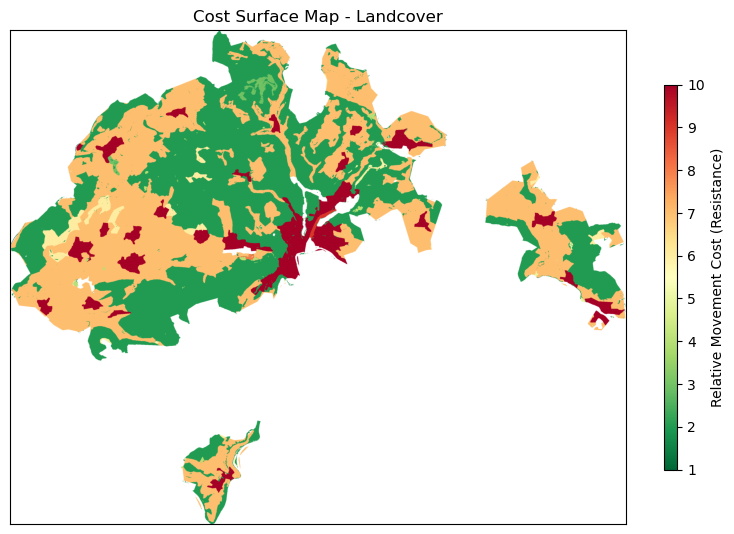

In [146]:
import matplotlib.pyplot as plt
import numpy as np

# Definiere die Figur und Axes
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Definiere und konfiguriere die Colormap
cmap_name = 'RdYlGn_r'
cmap = plt.cm.get_cmap(cmap_name) 
cmap.set_bad('white')

# Zeige das Bild
image = ax.imshow(
    cost_surface_landcover, 
    cmap=cmap,           
    extent=[xmin, xmax, ymin, ymax],
    vmin=1,
    vmax=10,
)

# --- ANPASSUNG DER COLORBAR ---
# 1. 'shrink' verkleinert die Länge der Colorbar (hier: 0.5 = 50% der ursprünglichen Achsenlänge).
# 2. 'aspect' steuert das Verhältnis von Länge zu Breite.
cbar = fig.colorbar(
    image, 
    ax=ax, 
    ticks=np.arange(1, 11, 1),
    shrink=0.5,     # <--- Verkleinert die Colorbar auf 50% der Originalgröße
    aspect=30       # <--- Erhöht das Seitenverhältnis (macht sie schlanker)
)
cbar.set_label('Relative Movement Cost (Resistance)')
# Remove axis elements for a map view
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

ax.set_title('Cost Surface Map - Landcover')

plt.tight_layout()
plt.show()

Water

In [130]:
# load swisstlm data
f_water = gpd.read_file(tlm_path, layer="tlm_gewaesser_fliessgewaesser")
s_water = gpd.read_file(tlm_path, layer="tlm_gewaesser_stehendes_gewaesser")

print(len(f_water))

# Clip: only objects within sh borders
f_water_sh = gpd.clip(f_water, sh)
s_water_sh = gpd.clip(s_water, sh)

print(len(f_water_sh))
print(f_water_sh.head())

660724
1938
                                          uuid datum_aenderung  \
353216  {F984319B-1C60-4FC3-8CC6-AC7F0C91E535}      2019-11-11   
16085   {1422C68C-F9FA-401B-B096-C87F21C7B95C}      2019-11-07   
453498  {8DE91387-AB4D-433C-B2F0-E7210BC0DD94}      2019-11-04   
15652   {E81EDDB1-BFEA-4FF3-A61D-A031A4C75D9B}      2019-11-05   
15956   {8A947B96-5954-47A2-AD21-CABC3293AAE7}      2016-12-01   

       datum_erstellung  erstellung_jahr  erstellung_monat grund_aenderung  \
353216       2015-08-10             2013               6.0      Verbessert   
16085        2008-01-25             2000               NaN      Verbessert   
453498       2016-12-05             2016               6.0      Verbessert   
15652        2008-01-25             2000               NaN      Verbessert   
15956        2008-01-25             2000               NaN      Verbessert   

         herkunft  herkunft_jahr  herkunft_monat        objektart  ...  name  \
353216  swisstopo           2019          

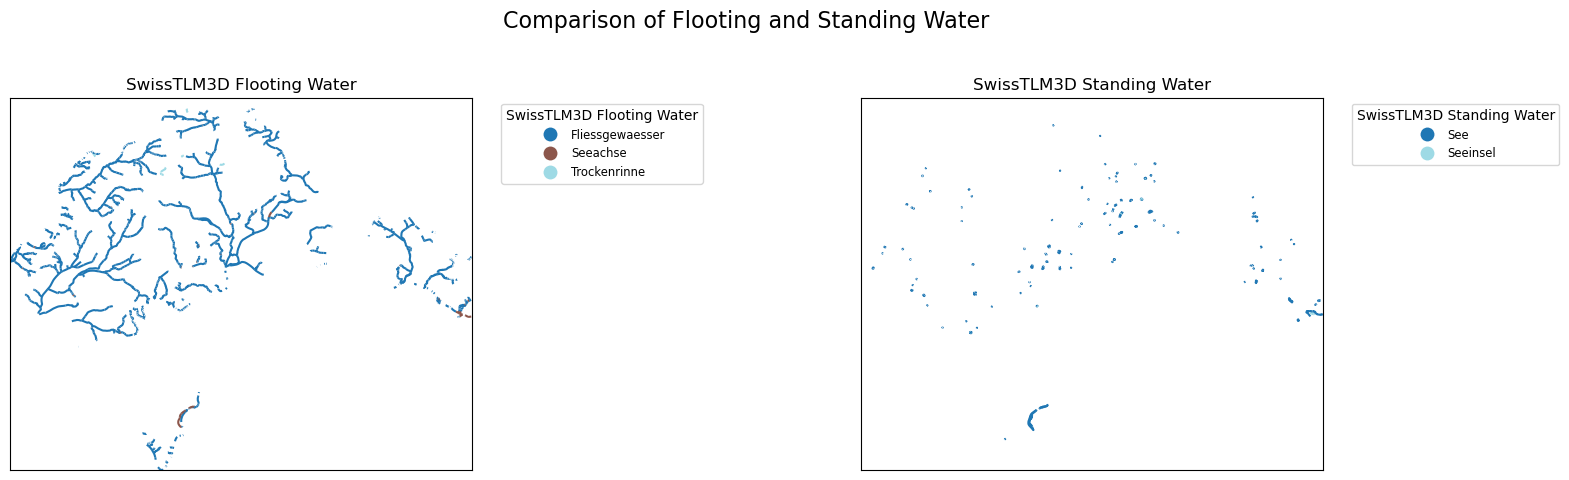

In [131]:
import matplotlib.pyplot as plt

# Set up the figure and two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 5)) # Increased width for external legends

# Plot 1: SwissTLM3D Landcover
f_water_sh.plot(
    column='objektart', 
    ax=axes[0], 
    legend=True, 
    legend_kwds={
        'title': "SwissTLM3D Flooting Water",
        'loc': 'upper left',       # Anchor the legend in the upper left corner of the bbox
        'bbox_to_anchor': (1.05, 1), # Position it to the right of the axes[0] plot
        'fontsize': 'small'
    },
    cmap='tab20'
)
axes[0].set_title('SwissTLM3D Flooting Water')

# Plot 2: Corine Landcover (CLC)
s_water_sh.plot(
    column='objektart',
    ax=axes[1],
    legend=True,
    legend_kwds={
        'title': "SwissTLM3D Standing Water",
        'loc': 'upper left',       # Anchor the legend in the upper left corner of the bbox
        'bbox_to_anchor': (1.05, 1), # Position it to the right of the axes[1] plot
        'fontsize': 'small'
    },
    cmap='tab20'
)
axes[1].set_title('SwissTLM3D Standing Water')

# **Optional but recommended:** Set common map limits if comparing the same area
# Use the bounds of the more detailed dataset (SwissTLM3D) to zoom in the view
x_min, y_min, x_max, y_max = landcover_sh.total_bounds
axes[0].set_xlim(x_min, x_max)
axes[0].set_ylim(y_min, y_max)
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(y_min, y_max)

# Remove axis labels/ticks for a cleaner map look
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

# Display the plots
plt.suptitle("Comparison of Flooting and Standing Water", fontsize=16)
# Use 'tight_layout' to automatically adjust subplots and make room for the legends.
# Note: Since we've used bbox_to_anchor, we often rely on tight_layout to finalize spacing.
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

In [132]:
water_combined = pd.concat([f_water_sh, s_water_sh], ignore_index=True)

In [133]:
# Ensure the result is still a GeoDataFrame and reset the index
water_combined = gpd.GeoDataFrame(water_combined, crs=f_water_sh.crs)
water_combined.reset_index(drop=True, inplace=True)

In [134]:
water_names_en = {
    'Bisse Suone': 'Bisse Suone (Irrigation Channel)',
    'Druckleitung einfach': 'Simple Pressure Pipe',
    'Druckleitung mehrfach': 'Multiple Pressure Pipes',
    'Druckstollen': 'Pressure Tunnel',
    'Fliessgewaesser': 'Flowing Water / Water Course',
    'Seeachse': 'Lake Axis',
    'Trockenrinne': 'Dry Gully / Dry Channel',
    'Seeinsel': 'Lake Island',
    'See': 'Lake / Standing Water Body'
}

water_combined['Standard_Name'] = water_combined['objektart'].map(water_names_en)

In [135]:
# --- Cost Mapping (English Name -> Cost Value) ---
cost_map_en = {
    'Flowing Water / Water Course': 10,
    'Lake / Standing Water Body': 10,
    'Lake Axis': 10,
    'Lake Island': 10,
    'Dry Gully / Dry Channel': 5, # Slightly lower cost
    'Simple Pressure Pipe': 10,
    'Multiple Pressure Pipes': 10,
    'Pressure Tunnel': 10,
    'Bisse Suone (Irrigation Channel)': 8
}

water_combined['Cost_Value'] = water_combined['Standard_Name'].map(cost_map_en)

In [136]:
# --- 2. Raster-Parameter definieren ---
resolution_meters = 10 # Feine Auflösung
xmin, ymin, xmax, ymax = water_combined.total_bounds

width_in_meters = xmax - xmin
height_in_meters = ymax - ymin
cols = int(np.ceil(width_in_meters / resolution_meters))
rows = int(np.ceil(height_in_meters / resolution_meters))

transform = from_bounds(xmin, ymin, xmax, ymax, cols, rows)

# NoData Wert
fill_value = 0 
out_shape = (rows, cols)

# shapes: Geometrie-Objekte und ihre Cost_Value
# Nur Features mit einem definierten Kostenwert werden gerastert (Cost_Value > 0)
shapes = [(geom, value) for geom, value in zip(water_combined.geometry, water_combined.Cost_Value.fillna(0)) if value > 0]

# Rasterisierung durchführen
cost_surface_water = rasterize(
    shapes=shapes,
    out_shape=out_shape,
    transform=transform,
    fill=fill_value,
    all_touched=True, 
    dtype=np.int16
)

C:\Users\Lukas\AppData\Local\Temp\ipykernel_9072\3987470107.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlGn_r')


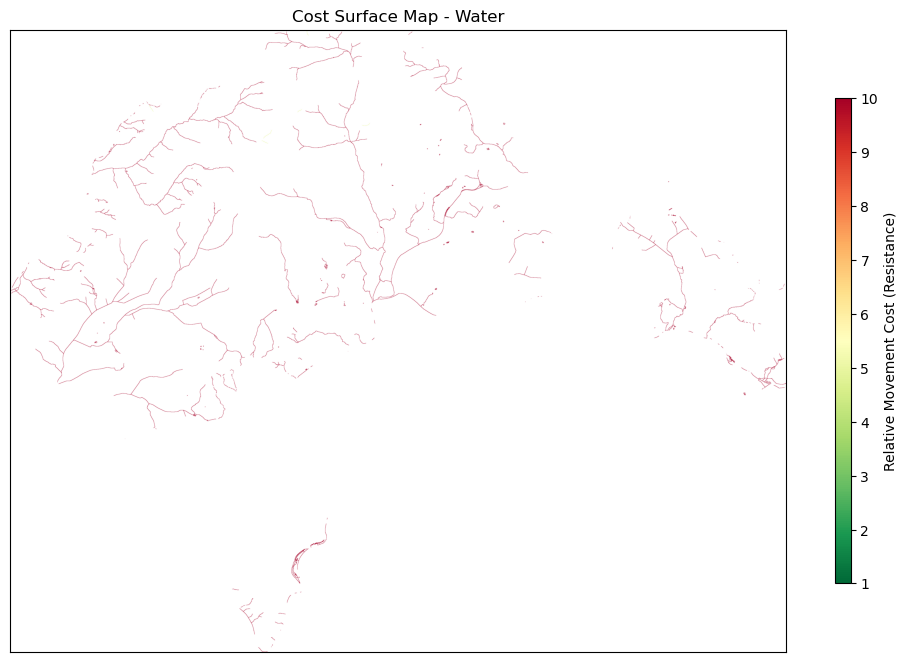

In [147]:
# Erstelle das maskierte Array (NoData = 0 soll weiß sein)
cost_surface_water = np.ma.masked_where(cost_surface_water == fill_value, cost_surface_water)

# Verwende 'Reds' für die Visualisierung der Kosten (je höher die Kosten, desto röter)
cmap = plt.cm.get_cmap('RdYlGn_r') 
cmap.set_bad('white') # NoData (0) wird weiß dargestellt

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Zeige das Bild
image = ax.imshow(
    cost_surface_water, 
    cmap=cmap,           
    extent=[xmin, xmax, ymin, ymax],
    vmin=1,
    vmax=10,
)

# --- ANPASSUNG DER COLORBAR ---
# 1. 'shrink' verkleinert die Länge der Colorbar (hier: 0.5 = 50% der ursprünglichen Achsenlänge).
# 2. 'aspect' steuert das Verhältnis von Länge zu Breite.
cbar = fig.colorbar(
    image, 
    ax=ax, 
    ticks=np.arange(1, 11, 1),
    shrink=0.5,     # <--- Verkleinert die Colorbar auf 50% der Originalgröße
    aspect=30       # <--- Erhöht das Seitenverhältnis (macht sie schlanker)
)
cbar.set_label('Relative Movement Cost (Resistance)')
# Remove axis elements for a map view
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

ax.set_title('Cost Surface Map - Water')

plt.tight_layout()
plt.show()

Roads

In [138]:
layers = fiona.listlayers(tlm_path)
print(f"tlm layers: {layers}") 

tlm layers: ['tlm_strassen_aus_einfahrt', 'tlm_bb_bodenbedeckung', 'tlm_bb_einzelbaum_gebuesch', 'tlm_eo_einzelobjekt', 'tlm_oev_eisenbahn', 'tlm_gewaesser_fliessgewaesser', 'tlm_namen_flurname', 'tlm_areale_freizeitareal', 'tlm_bauten_gebaeude_footprint', 'tlm_namen_gebietsname', 'tlm_name_gelaendename', 'tlm_oev_haltestelle', 'tlm_bauten_leitung', 'tlm_bauten_mauer', 'tlm_namen_name_pkt', 'tlm_areale_nutzungsareal', 'tlm_oev_schifffahrt', 'tlm_areale_schutzgebiet', 'tlm_namen_siedlungsname', 'tlm_bauten_sportbaute_lin', 'tlm_bauten_sportbaute_ply', 'tlm_bauten_staubaute', 'tlm_gewaesser_stehendes_gewaesser', 'tlm_strassen_strasse', 'tlm_strassen_strasseninfo', 'tlm_oev_uebrige_bahn', 'tlm_bauten_verbauung', 'tlm_areale_verkehrsareal', 'tlm_bauten_verkehrsbaute_lin', 'tlm_bauten_verkehrsbaute_ply', 'tlm_bauten_versorgungsbaute_pkt', 'tlm_bb_glamos', 'tlm_bauten_leitung_stromtrasse', 'tlm_areale_nutzungsareal_schule', 'tlm_areale_schule', 'tlm_strassen_strassenname', 'tlm_strassen_stra

In [139]:
import geopandas as gpd
# Die GeoDataFrame 'sh' (Kanton Schaffhausen) muss bereits definiert sein.

# 1. Extrahiere die Bounding Box des Kantons Schaffhausen (sh.total_bounds)
#    gpd.GeoDataFrame.total_bounds gibt ein Tupel (xmin, ymin, xmax, ymax) zurück.
xmin, ymin, xmax, ymax = sh.total_bounds
sh_bbox = (xmin, ymin, xmax, ymax)

# 2. Lade NUR die Features, die die Bounding Box des Kantons überlappen.
#    Dieser Schritt ist um Größenordnungen schneller als das Laden der gesamten Schweiz.
roads = gpd.read_file(
    tlm_path, 
    layer="tlm_strassen_strasse",
    bbox=sh_bbox  # <-- Hier wird der räumliche Filter angewendet.
)

print(f"Anzahl geladener Straßen-Features im Bounding Box von SH: {len(roads)}")

# 3. Präzises Clipping (für den Feinschliff an der Kantonsgrenze)
#    Der bbox-Filter ist nur ein rechteckiger Vorfilter. Das eigentliche Clipping ist noch nötig,
#    ist aber jetzt viel schneller, da 'roads' nur eine kleine Teilmenge enthält.
roads_sh = gpd.clip(roads, sh)

print(f"Anzahl finaler Straßen-Features in SH: {len(roads_sh)}")

Anzahl geladener Straßen-Features im Bounding Box von SH: 62170
Anzahl finaler Straßen-Features in SH: 27026


In [140]:
road_cost_map = {
    '10m Strasse': {'en': '10m Road', 'cost': 10}, 
    '8m Strasse': {'en': '8m Road', 'cost': 10}, 
    '6m Strasse': {'en': '6m Road', 'cost': 9}, 
    '4m Strasse': {'en': '4m Road', 'cost': 8},
    '3m Strasse': {'en': '3m Road', 'cost': 7}, 
    '2m Weg': {'en': '2m Path', 'cost': 6}, 
    '1m Weg': {'en': '1m Path', 'cost': 5}, 
    '2m Wegfragment': {'en': '2m Path Fragment', 'cost': 4},
    '1m Wegfragment': {'en': '1m Path Fragment', 'cost': 3}, 
    'Autostrasse': {'en': 'Expressway', 'cost': 10}, # Impassable
    'Ausfahrt': {'en': 'Exit', 'cost': 10}, 
    'Einfahrt': {'en': 'Entrance', 'cost': 10}, 
    'Dienstzufahrt': {'en': 'Service Access', 'cost': 8}, 
    'Zufahrt': {'en': 'Access Road', 'cost': 8}, 
    'Verbindung': {'en': 'Connection', 'cost': 8}, 
    'Platz': {'en': 'Square/Plaza', 'cost': 5}, 
    'Raststaette': {'en': 'Rest Stop', 'cost': 6}, 
    'Faehre': {'en': 'Ferry', 'cost': 10}
}

C:\Users\Lukas\AppData\Local\Temp\ipykernel_9072\1940690414.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlGn_r')


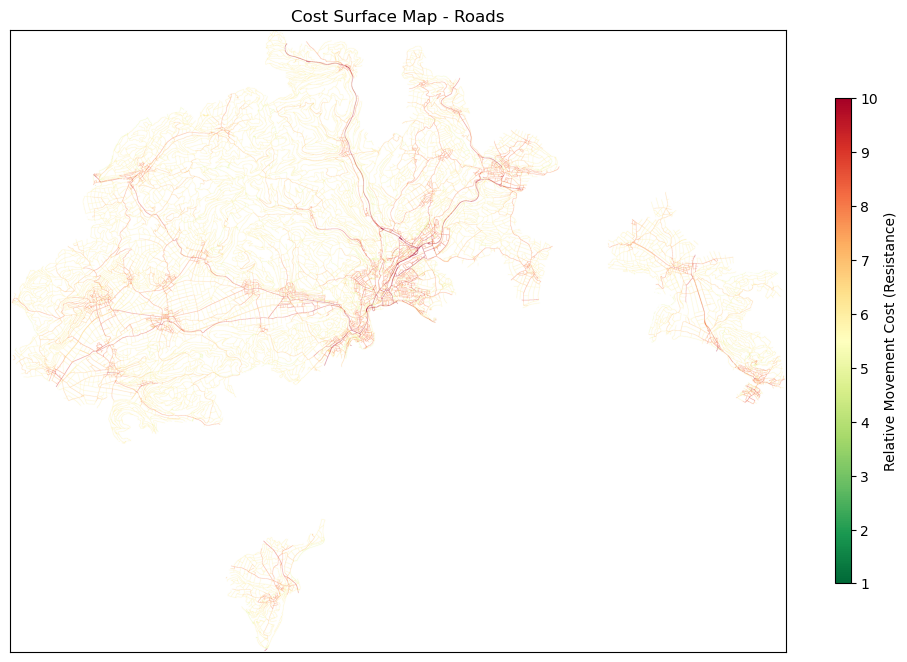

In [148]:
import geopandas as gpd
import numpy as np
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_bounds
import matplotlib.pyplot as plt
from shapely.geometry import LineString

# Apply Cost Mapping
roads_sh['Cost_Value'] = roads_sh['objektart'].apply(lambda x: road_cost_map[x]['cost'])
roads_sh['English_Name'] = roads_sh['objektart'].apply(lambda x: road_cost_map[x]['en'])

# 3. Rasterize Parameters
resolution_meters = 10
xmin, ymin, xmax, ymax = roads_sh.total_bounds
padding = 50 
xmin, ymin, xmax, ymax = xmin - padding, ymin - padding, xmax + padding, ymax + padding

width_in_meters = xmax - xmin
height_in_meters = ymax - ymin
cols = int(np.ceil(width_in_meters / resolution_meters))
rows = int(np.ceil(height_in_meters / resolution_meters))

transform = from_bounds(xmin, ymin, xmax, ymax, cols, rows)
fill_value = 0 
out_shape = (rows, cols)

# Shapes for rasterization
shapes = [(geom, value) for geom, value in zip(roads_sh.geometry, roads_sh.Cost_Value.fillna(0)) if value > 0]

# Rasterization
cost_surface_roads = rasterize(
    shapes=shapes,
    out_shape=out_shape,
    transform=transform,
    fill=fill_value,
    all_touched=True, 
    dtype=np.int16
)

# 4. Plot the Cost Surface
cost_surface_roads = np.ma.masked_where(cost_surface_roads == fill_value, cost_surface_roads)

# Green (low cost) -> Red (high cost/impassable)
cmap = plt.cm.get_cmap('RdYlGn_r') 
cmap.set_bad('white') 

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

image = ax.imshow(
    cost_surface_roads,
    cmap=cmap,
    extent=[xmin, xmax, ymin, ymax],
    vmin=1,    # Min cost defined by roads/access
    vmax=10,  # Max cost defined by expressway
)

cbar = fig.colorbar(
    image, 
    ax=ax, 
    ticks=np.arange(1, 11, 1),
    shrink=0.5,     # <--- Verkleinert die Colorbar auf 50% der Originalgröße
    aspect=30       # <--- Erhöht das Seitenverhältnis (macht sie schlanker)
)
cbar.set_label('Relative Movement Cost (Resistance)')

ax.set_title('Cost Surface Map - Roads')
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

Steepness

evtl. Noise

Final Model

In [142]:
# import numpy as np
# import matplotlib.pyplot as plt


# # MOCK SETUP: Create cost arrays for demonstration (100x100 grid)
# rows, cols = 100, 100
# fill_value = 0
# cost_surface_landcover = np.random.randint(1, 11, size=(rows, cols), dtype=np.int16)
# cost_surface_water = np.random.randint(1, 11, size=(rows, cols), dtype=np.int16)
# cost_surface_roads = np.random.randint(1, 11, size=(rows, cols), dtype=np.int16)

# # Set some areas to NoData (fill_value) for demonstration
# cost_surface_landcover[10:20, 10:20] = fill_value
# cost_surface_water[30:40, 30:40] = fill_value
# cost_surface_roads[50:60, 50:60] = fill_value

# # Mock Bounds
# xmin, ymin, xmax, ymax = 2690000, 1260000, 2690500, 1260500 

# # --- End MOCK SETUP ---

In [150]:
len(cost_surface_roads)

2848

In [151]:
len(cost_surface_landcover)

2841

In [152]:
len(cost_surface_water)

2768

In [156]:
lc_cost_array, lc_transform, lc_shape, lc_bounds = create_cost_raster(
    gdf=landcover_filtered, 
    cost_column='Cost_Value' # Assuming this column exists in landcover_filtered (1-10)
)

water_cost_array, water_transform, water_shape, water_bounds = create_cost_raster(
    gdf=water_combined, 
    cost_column='Cost_Value' # Assuming this column exists in water_combined (1-10)
)

roads_cost_array, roads_transform, roads_shape, roads_bounds = create_cost_raster(
    gdf=roads_sh, 
    cost_column='Cost_Value' # Assuming this column exists in roads_sh (1-10)
)

# Now, lc_cost_array, water_cost_array, and roads_cost_array are guaranteed
# to have the exact same shape (lc_shape == water_shape == roads_shape) 
# and can be safely stacked using np.stack().

In [158]:
# 1. Create a stack of the input arrays
cost_stack = np.stack([
    lc_cost_array, 
    water_cost_array, 
    roads_cost_array
])

# 2. Calculate the maximum value at each pixel location
#    The maximum cost value will determine the final resistance.
final_cost_surface_array = np.max(cost_stack, axis=0)

# 3. Handle No-Data: If ANY input layer had a value, the output has a value (max value).
#    The final pixel is only 'No Data' (fill_value) if ALL inputs were 'No Data' at that pixel.
is_no_data = (lc_cost_array == fill_value) & \
             (water_cost_array == fill_value) & \
             (roads_cost_array == fill_value)

# Apply the max value only where there was at least one cost value (> fill_value)
final_cost_surface_array[is_no_data] = fill_value

print("Final Combined Cost Surface array created.")

Final Combined Cost Surface array created.


In [159]:
xmin, ymin, xmax, ymax = sh.total_bounds

C:\Users\Lukas\AppData\Local\Temp\ipykernel_9072\1053936193.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlGn_r')


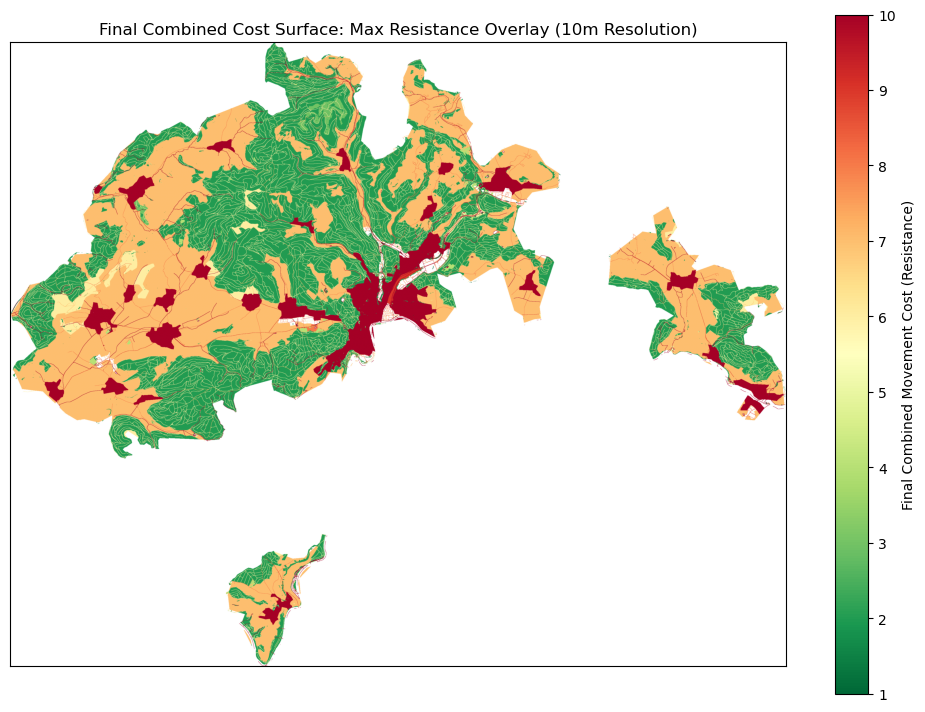

In [161]:
final_cost_surface_array = np.ma.masked_where(final_cost_surface_array == fill_value, final_cost_surface_array)

cmap = plt.cm.get_cmap('RdYlGn_r') 
cmap.set_bad('white') 

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

image = ax.imshow(
    final_cost_surface_array,
    cmap=cmap,
    # Use the definitive total bounds for the extent
    extent=[xmin, xmax, ymin, ymax],
    vmin=1,   
    vmax=10,  # Assuming all final costs range from 1 to 10
)

cbar = fig.colorbar(image, ax=ax, ticks=np.arange(1, 11, 1), shrink=0.7)
cbar.set_label('Final Combined Movement Cost (Resistance)')
cbar.ax.set_yticklabels(np.arange(1, 11, 1))

ax.set_title('Final Combined Cost Surface: Max Resistance Overlay (10m Resolution)')
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()